In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


Load and Preprocess Fashion-MNIST Dataset

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


Define Deep Feedforward Neural Network (3 Hidden Layers)

In [9]:
class DeepNN(nn.Module):
    def __init__(self, activation):
        super(DeepNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(784, 512),
            activation,
            nn.Linear(512, 256),
            activation,
            nn.Linear(256, 128),
            activation,
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


Training and Evaluation Function

In [10]:
def train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        correct, total, loss_sum = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        acc = 100 * correct / total
        print(f"Epoch {epoch+1}: Loss={loss_sum:.4f}, Accuracy={acc:.2f}%")

    # Test accuracy
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total


Advanced Task 2: Activation Function Comparison

In [11]:
activations = {
    "ReLU": nn.ReLU(),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(0.01)
}

results = {}

for name, act in activations.items():
    print(f"\nTraining with {name}")
    model = DeepNN(act)
    acc = train_and_evaluate(model, train_loader, test_loader)
    results[name] = acc



Training with ReLU
Epoch 1: Loss=469.4602, Accuracy=81.67%
Epoch 2: Loss=351.2308, Accuracy=86.33%
Epoch 3: Loss=315.1407, Accuracy=87.61%
Epoch 4: Loss=287.1157, Accuracy=88.64%
Epoch 5: Loss=269.7059, Accuracy=89.39%
Epoch 6: Loss=252.8557, Accuracy=89.94%
Epoch 7: Loss=239.0876, Accuracy=90.48%
Epoch 8: Loss=225.6557, Accuracy=91.01%
Epoch 9: Loss=212.4699, Accuracy=91.45%
Epoch 10: Loss=204.2024, Accuracy=91.78%

Training with Sigmoid
Epoch 1: Loss=679.5869, Accuracy=73.28%
Epoch 2: Loss=390.5933, Accuracy=85.06%
Epoch 3: Loss=337.7852, Accuracy=86.97%
Epoch 4: Loss=311.4905, Accuracy=87.96%
Epoch 5: Loss=287.0969, Accuracy=88.93%
Epoch 6: Loss=271.9871, Accuracy=89.40%
Epoch 7: Loss=256.5919, Accuracy=90.08%
Epoch 8: Loss=247.3962, Accuracy=90.42%
Epoch 9: Loss=233.6699, Accuracy=90.89%
Epoch 10: Loss=222.5075, Accuracy=91.25%

Training with Tanh
Epoch 1: Loss=478.3795, Accuracy=81.49%
Epoch 2: Loss=367.5643, Accuracy=85.72%
Epoch 3: Loss=334.7150, Accuracy=86.93%
Epoch 4: Loss=3

Printing Comparison Results

In [12]:
print("\nActivation Function Comparison:")
for k, v in results.items():
    print(f"{k}: Test Accuracy = {v:.2f}%")



Activation Function Comparison:
ReLU: Test Accuracy = 88.27%
Sigmoid: Test Accuracy = 88.21%
Tanh: Test Accuracy = 87.25%
LeakyReLU: Test Accuracy = 88.92%



- ReLU and Leaky ReLU perform better because they allow efficient gradient flow and faster learning.

- Sigmoid and Tanh perform slightly worse due to saturation and vanishing gradient issues.

- The small gap between training accuracy (91-92%) and test accuracy (88-89%) indicates good generalization with no severe overfitting.

Advanced Task 3: Hidden Layer Activation Visualization

In [13]:
def get_hidden_layer_activations(model, image):
    hidden_acts = []
    x = image.view(1, -1)

    for layer in model.net:
        x = layer(x)
        if isinstance(layer, nn.Linear) and x.shape[1] != 10:
            hidden_acts.append(x.detach())

    return hidden_acts


Visualize Activations

In [14]:
image, _ = train_dataset[0]

model = DeepNN(nn.ReLU())
hidden_acts = get_hidden_layer_activations(model, image)


In [15]:
print(type(hidden_acts))
print(type(hidden_acts[0]))


<class 'list'>
<class 'torch.Tensor'>


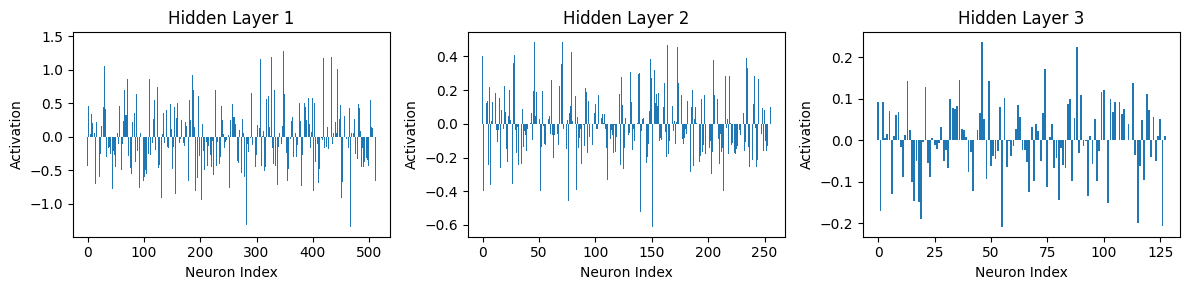

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

for i, act in enumerate(hidden_acts):
    plt.subplot(1, len(hidden_acts), i+1)
    plt.bar(range(act.shape[1]), act[0].cpu().numpy())
    plt.title(f"Hidden Layer {i+1}")
    plt.xlabel("Neuron Index")
    plt.ylabel("Activation")

plt.tight_layout()
plt.show()


#Explanation of Graphs

Each graph shows the activation values of neurons in a hidden layer for a single input image.

###Hidden Layer 1:
Many neurons are active with larger variations, indicating extraction of low-level features from raw pixels.

###Hidden Layer 2:
Activations become more controlled and selective, showing feature combination and refinement.

###Hidden Layer 3:
Fewer neurons show strong activation, representing high-level, abstract features useful for classification.

Overall, the graphs show that as depth increases, neuron activations become more selective, confirming hierarchical feature learning.

#Interpretation of Results

###1. Trade-off Between Depth and Overfitting

Increasing network depth improves the model’s ability to learn complex patterns, but also increases the risk of overfitting. In this experiment, a network with three hidden layers achieved high test accuracy with only a small gap between training and test accuracy, indicating good generalization without overfitting.

###2. Why Some Activations Perform Better

ReLU and Leaky ReLU achieved higher test accuracy than Sigmoid and Tanh. This is because ReLU-based activations reduce the vanishing gradient problem and allow faster convergence in deep networks, while Sigmoid and Tanh saturate and slow down learning.

###3. Feature Transformation Across Layers

Early hidden layers capture low-level pixel patterns, intermediate layers learn meaningful feature combinations, and deeper layers represent abstract, class-specific features. Activation plots show decreasing and more selective neuron activations as depth increases, confirming hierarchical feature learning.

###Final Conclusion

A moderately deep network with ReLU-based activations provides the best balance between learning capacity and generalization for Fashion-MNIST classification.